# Marketing Analytics - Homework 2

Author: *Colombini Francesco*

ID Number: 944941

### Context:

You have recently joined the marketing analytics team of an FMCG retailer.

Senior management would like to answer the following questions:

1. Which customers generate the highest value?
2. Which customers are at risk of churn?
3. How should marketing resources be allocated across customer segments?
4. What customer retention strategies should be implemented?
5. Which customers should be prioritized for loyalty programs?

Your analysis should provide evidence-based recommendations to support managerial decision making.

## Part A - Data Understanding and Preparation

In [5]:
# Import of all the libraries used in the script
import numpy as np
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes.utils import calibration_and_holdout_data
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns


# Docker parameters for PostgreSQL connection (In a real worl project should be stored in a .env file inserted in .gitignore)
DB_PARAMS = {
    'dbname': 'test',
    'user': 'admin',
    'password': 'admin',
    'host': 'localhost',
    'port': 5432
}


# Following the ER diagram, the parent tables must be loaded before child tables 
# This is made to respect Foreign Key constraints creating a logical order of loading the data
# Level 1 (no dependencies) -> Level 2 -> Level 3 -> Engagement tables
LOAD_ORDER = [
    # Level 1 - No foreign key dependencies
    'CATEGORY.csv',
    'CHANNEL.csv',
    'STORE.csv',
    'CUSTOMER.csv',
    'PROMOTION.csv',
    # Level 2 - Depend on Level 1
    'PRODUCT.csv',
    'ORDER.csv',
    # Level 3 - Depend on Level 2
    'ORDER_ITEM.csv',
    'PRICE_CHANGE.csv',
    # Engagement tables - Depend on CUSTOMER and STORE
    'SESSION.csv',
    'SUPPORT_TICKET.csv',
    'CAMPAIGN_TOUCH.csv',
    'EXTERNAL_FACTOR.csv',
    'MARKETING_CHANNEL.csv',
]

# Creation of the script in SQL to create the database schema
DDL_QUERY = """
-- Level 1: No foreign key dependencies
-- Creation of the dimensional tables that tend to be fixed in the time
CREATE TABLE IF NOT EXISTS CATEGORY (
    category_id VARCHAR PRIMARY KEY,
    category_name VARCHAR
);

CREATE TABLE IF NOT EXISTS CHANNEL (
    channel_id VARCHAR PRIMARY KEY,
    channel_name VARCHAR
);

CREATE TABLE IF NOT EXISTS STORE (
    store_id VARCHAR PRIMARY KEY,
    store_city VARCHAR,
    store_state VARCHAR,
    store_type VARCHAR
);

CREATE TABLE IF NOT EXISTS CUSTOMER (
    customer_id VARCHAR PRIMARY KEY,
    signup_date DATE,
    city VARCHAR,
    state VARCHAR,
    segment VARCHAR,
    status VARCHAR
);

CREATE TABLE IF NOT EXISTS PROMOTION (
    promo_id VARCHAR PRIMARY KEY,
    promo_type VARCHAR,
    start_date DATE,
    end_date DATE,
    discount_value FLOAT
);




-- Level 2: Depend on Level 1
-- Product Table
CREATE TABLE IF NOT EXISTS PRODUCT (
    product_id VARCHAR PRIMARY KEY,
    category_id VARCHAR REFERENCES CATEGORY(category_id),
    brand VARCHAR,
    sku_name VARCHAR
);

-- Order Table
CREATE TABLE IF NOT EXISTS "ORDER" (
    order_id VARCHAR PRIMARY KEY,
    customer_id VARCHAR REFERENCES CUSTOMER(customer_id),
    order_date DATE,
    store_id VARCHAR REFERENCES STORE(store_id),
    channel_id VARCHAR REFERENCES CHANNEL(channel_id),
    payment_type VARCHAR,
    year INT,
    week INT
);




-- Level 3: Depend on Level 2
-- Specific order table
CREATE TABLE IF NOT EXISTS ORDER_ITEM (
    order_item_id VARCHAR PRIMARY KEY,
    order_id VARCHAR REFERENCES "ORDER"(order_id),
    product_id VARCHAR REFERENCES PRODUCT(product_id),
    promo_id VARCHAR REFERENCES PROMOTION(promo_id),
    quantity INT,
    item_discount FLOAT
);

-- Historical price changes for each product
CREATE TABLE IF NOT EXISTS PRICE_CHANGE (
    product_id VARCHAR REFERENCES PRODUCT(product_id),
    year INT,
    week INT,
    unit_price FLOAT,
    PRIMARY KEY (product_id, year, week)
);




-- Engagement tables: depend on CUSTOMER or STORE
CREATE TABLE IF NOT EXISTS SESSION (
    session_id           VARCHAR PRIMARY KEY,
    customer_id          VARCHAR REFERENCES CUSTOMER(customer_id),
    session_start        TIMESTAMP,
    session_duration_sec INT,
    pages_viewed         INT,
    device               VARCHAR,
    referrer             VARCHAR
);

CREATE TABLE IF NOT EXISTS SUPPORT_TICKET (
    ticket_id          VARCHAR PRIMARY KEY,
    customer_id        VARCHAR REFERENCES CUSTOMER(customer_id),
    created_date       DATE,
    issue_type         VARCHAR,
    status             VARCHAR,
    resolution_time_hr INT,
    csat_score         INT
);

CREATE TABLE IF NOT EXISTS CAMPAIGN_TOUCH (
    touch_id      VARCHAR PRIMARY KEY,
    customer_id   VARCHAR REFERENCES CUSTOMER(customer_id),
    touch_date    DATE,
    channel       VARCHAR,
    campaign_name VARCHAR,
    outcome       VARCHAR
);

-- Depends on STORE
CREATE TABLE IF NOT EXISTS EXTERNAL_FACTOR (
    factor_id   VARCHAR PRIMARY KEY,
    store_id    VARCHAR REFERENCES STORE(store_id),
    factor_date DATE,
    is_holiday  BOOLEAN,
    temp_c      FLOAT,
    rainfall_mm FLOAT,
    trend_index FLOAT,
    cpi_index   FLOAT,
    year INT,
    week INT
);

CREATE TABLE IF NOT EXISTS MARKETING_CHANNEL (
    channel_id   VARCHAR PRIMARY KEY,
    channel_name VARCHAR,
    channel_type VARCHAR,
    cost_tier    VARCHAR
);
"""

In [ ]:
# Function to connect to the PostgreSQL database and execute the DDL script to create the schema
def setup_database():
    try:
        with psycopg2.connect(**DB_PARAMS) as infrastructure:
            print("Successfully connected to the database PostgreSQL (in Docker).")
            
            with infrastructure.cursor() as execution:
                print("Executing the DDL script...")
                execution.execute(DDL_QUERY) # execution of the SQL script to create the database schema
                infrastructure.commit() # Saving of the changes in the database
                print("Operation completed: dimensional schema created successfully.")
                
    except Exception as error:
        print(f"Error during the operation: {error}")


# Dynamic ingestion function to insert data from a DataFrame into the specified table, using the provided columns
def ingest_table(conn, df: pd.DataFrame, table_name: str, columns: list):

    csv_columns = df.columns.tolist() # Check that CSV columns match the expected DDL columns
    missing = [col for col in columns if col not in csv_columns]
    if missing:
        print(f"[SKIP] {table_name}: missing columns {missing}")
        return

    cur = conn.cursor() #connection to the database
    col_str = ', '.join(columns) # transform the list of columns into a string separated by commas for the SQL query
    placeholders = ', '.join(['%s'] * len(columns)) # match the number of insertion with the number of columns
    sql = f"INSERT INTO {table_name} ({col_str}) VALUES ({placeholders}) ON CONFLICT DO NOTHING" # SQL query to insert data into the table, 
    # this avoid potential conflicts by ignoring them
    
    for _, row in df.iterrows():
        cur.execute(sql, tuple(row[col] for col in columns)) #execution of the SQL query for each row of the DataFrame, passing the values as a tuple
        # in this way psycopg2 can substitute the values of %s with the real values
    
    conn.commit() # Saving of the changes in the database
    print(f"{table_name}: {len(df)} rows inserted.")


def ingest_all():
    conn = psycopg2.connect(**DB_PARAMS) #connection with postgreSQL database
    
    for filename in LOAD_ORDER: # loop through the list of files in the specified order
        table_name = filename.replace('.csv', '') # transform the filename into the table name by removing .csv
        
        if table_name == 'ORDER':
            table_name = '"ORDER"' # ORDER is a reserved keyword in SQL, so it needs to be quoted to be used as a table name
        
        df = pd.read_csv(f'Data/{filename}') # read with pandas and parse dates in the correct format
        # Dynamically convert date columns and try parsing any string column as a date to solve potential date issues
        for col in df.columns:
            if df[col].dtype == 'object':
                try:
                    df[col] = pd.to_datetime(df[col], format='%d-%m-%Y')
                except:
                    pass
        df = df.where(pd.notnull(df), None) # Replace NaN with None for proper insertion into PostgreSQL
        ingest_table(conn, df, table_name, df.columns.tolist()) # use the ingestion function created above
            
    conn.close() # close the connection with the database
    print("Ingestion complete.")


def load_main_dataset(conn) -> pd.DataFrame:
    # We select only the relevant columns for the analysis and we join the tables to create a single dataset that contains all the information needed for the analysis
    query = """
    SELECT 
        o.order_id,
        o.customer_id,
        o.order_date,
        o.year,
        o.week,
        c.signup_date,
        c.city,
        c.state,
        c.segment,
        oi.quantity,
        oi.item_discount,
        p.product_id,
        p.brand,
        cat.category_name,
        pc.unit_price
    FROM "ORDER" o
    JOIN CUSTOMER c ON o.customer_id = c.customer_id
    JOIN ORDER_ITEM oi ON o.order_id = oi.order_id
    JOIN PRODUCT p ON oi.product_id = p.product_id
    JOIN CATEGORY cat ON p.category_id = cat.category_id
    JOIN PRICE_CHANGE pc ON p.product_id = pc.product_id 
        AND o.year = pc.year 
        AND o.week = pc.week
    """
    # We connect the table of the products with the specific value in the customer ID, 
    # then we connect the order to the order_item 
    # tham it that is connected to the product and the price change for that specific date (year + week) 
    # to have the price of the product at the moment of the order
    df = pd.read_sql(query, conn)
    print(f"Main dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
    return df



def data_quality(df: pd.DataFrame) -> None:

    # Missing Values handling
    print("\nMissing Values:")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({
        'missing_count': missing,
        'missing_%': missing_pct
    })
    if missing_df['missing_count'].sum() == 0:
        print("No missing values found in any column")
    else:
        print(missing_df[missing_df['missing_count'] > 0]) #shows if present any missing values


    #Descriptive Statistics
    print("\nDesriptive Statistics:")
    # Fix date columns
    for col in ['order_date', 'signup_date']:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col])

    # Identify column types automatically
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    date_cols = df.select_dtypes(include=['datetime64']).columns.tolist()
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

    # Exclude IDs from the EDA because they are not meaningful to describe
    exclude_cols = ['order_id', 'customer_id', 'product_id', 'category_id']
    analytic_numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

    print(f"Categorical columns : {categorical_cols}")
    print(f"Date columns : {date_cols}")
    print(f"Numeric (analytic) : {analytic_numeric_cols}")

    # Temporal range from year/week
    print(f"Temporal range:")
    print(f"Year: min: {df['year'].min()}, max: {df['year'].max()}")
    print(f"Week: min: {df['week'].min()}, max: {df['week'].max()}")

    analytic_numeric_cols = [col for col in analytic_numeric_cols if col not in ['year', 'week']]
    print(df[analytic_numeric_cols].describe())



def data_preparation(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    
    # Currency Conversion (INR -> USD)
    EXCHANGE_RATE = 83.0
    df['unit_price_usd'] = df['unit_price'] / EXCHANGE_RATE
    df['item_discount_usd'] = df['item_discount'] / EXCHANGE_RATE
    
    # Calcolate Gross Revenue for each line item (quantity * unit price)
    df['gross_revenue_usd'] = df['quantity'] * df['unit_price_usd']

    df['net_revenue_usd'] = df['gross_revenue_usd'] - df['item_discount_usd']
    
    # Aggregation by order_id to create the Orders dataset
    df_orders = df.groupby('order_id').agg({
        'customer_id': 'first',
        'order_date': 'first',
        'signup_date': 'first', 
        'year': 'first',
        'week': 'first',
        'gross_revenue_usd': 'sum',
        'item_discount_usd': 'max'
    }).reset_index()
    
    # Calcolate Net Revenue for each order
    df_orders['net_revenue_usd'] = df_orders['gross_revenue_usd'] - df_orders['item_discount_usd']
    df_orders['net_revenue_usd'] = df_orders['net_revenue_usd'].clip(lower=0)
    
    print(f"Dataset Items: {df.shape[0]} for each item.")
    print(f"Dataset Orders: {df_orders.shape[0]} unique orders.")
    
    return df, df_orders

In [ ]:

#!! RUN ONLY ONCE !!
#setup_database()
#ingest_all()
#print("Database setup and data ingestion completed successfully.")

conn = psycopg2.connect(**DB_PARAMS) # We open the connection at the beginning of the analysis
df_main = load_main_dataset(conn) # Load the query to identify the specific dataset for the analysis
conn.close() # We close the connection at the end of the loading

df_items, df_orders = data_preparation(df_main) # Perform data preparation steps to create the final datasets for the analysis, including currency conversion, revenue calculation, and aggregation at order level

data_quality(df_items) # Perform data quality checks on the prepared dataset
data_quality(df_orders) # Perform data quality checks on the grouped dataset


C:\Users\3003f\AppData\Local\Temp\ipykernel_40412\2231072374.py:96: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Main dataset loaded: 62767 rows, 15 columns
Dataset Items: 62767 for each item.
Dataset Orders: 56958 unique orders.

Missing Values:
No missing values found in any column

Desriptive Statistics:
Categorical columns : ['order_id', 'customer_id', 'city', 'state', 'segment', 'product_id', 'brand', 'category_name']
Date columns : ['order_date', 'signup_date']
Numeric (analytic) : ['year', 'week', 'quantity', 'item_discount', 'unit_price', 'unit_price_usd', 'item_discount_usd', 'gross_revenue_usd', 'net_revenue_usd']
Temporal range:
Year: min: 2023, max: 2025
Week: min: 1, max: 52
           quantity  item_discount    unit_price  unit_price_usd  \
count  62767.000000   62767.000000  62767.000000    62767.000000   
mean       1.339828      12.123339    592.380662        7.137116   
std        0.550706      38.121554    738.046143        8.892122   
min        1.000000       0.000000     23.170000        0.279157   
25%        1.000000       0.000000    130.500000        1.572289   
50%     

The dataset used in this analysis consists of 62,767 transactional records spanning three years (2023–2025), covering all 52 weeks per year. It was assembled by joining six core tables from the FMCG database: ORDER, CUSTOMER, ORDER_ITEM, PRODUCT, CATEGORY, and PRICE_CHANGE. NaN values were replaced with None before loading into PostgreSQL to guarantee clean column typing throughout the pipeline.

Rather than loading raw tables independently, a single SQL query was creted to extract only the 15 columns relevant to CLV analysis, keeping the dataset coherent by construction (minimality principle). One important decision was to set a JOIN with PRICE_CHANGE on the composite key `(product_id, year, week)` to eliminates price-period endogeneity. By joining on the precise year and week of each transaction, each revenue figure reflects the actual market price at which the purchase decision was made. The implicit trade-off is that only transactions with a matching PRICE_CHANGE record are included, an inner-join semantics choice that favours price accuracy over dataset completeness.

All monetary values were converted from Indian Rupees (INR) to USD using a fixed exchange rate of 83.0 INR/USD, applied uniformly across the entire dataset. Two revenue metrics are derived at line-item level: `gross_revenue_usd = quantity × unit_price_usd` and `net_revenue_usd = gross_revenue_usd − item_discount_usd`. At order aggregation, `item_discount_usd` is taken as the maximum across items within each order rather than the sum, because the discount field exhibits a heavily anomalous distribution. This pattern strongly suggests discounts were recorded at order level and mechanically distributed across individual item lines, making item-level summation unreliable. A floor of zero is then applied to prevent negative net revenue entries, from distorting the Monetary signal in downstream RFM and CLV calculations.

The resulting dataset contains 8 categorical variables, 3 numeric variables relevant to analysis, and 2 date columns. `year` and `week` are retained as temporal coordinates for the JOIN rather than treated as analytical metrics. No missing values were detected across any column.

## Part B - Exploratory Data Analysis

In [ ]:
def plot_spending_and_frequency(df_orders: pd.DataFrame) -> None:
    
    # Single client metrics calculation: total spending and purchase frequency
    customer_metrics = df_orders.groupby('customer_id').agg(
        total_spending=('net_revenue_usd', 'sum'),
        purchase_frequency=('order_id', 'count')
    ).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Customer Spending Distribution
    axes[0].hist(customer_metrics['total_spending'], bins=50, color='#ADD8E6', edgecolor='black')
    axes[0].set_title('1. Customer Spending Distribution', fontsize=14, pad=15)
    axes[0].set_xlabel('Total spending per customer (USD)', fontsize=12)
    axes[0].set_ylabel('Number of customers', fontsize=12)
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)
    axes[0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

    # Purchase Frequency Distribution
    max_freq = int(customer_metrics['purchase_frequency'].max())
    axes[1].hist(customer_metrics['purchase_frequency'], bins=range(1, max_freq + 2), color='#000080', edgecolor='black', align='left')
    axes[1].set_title('2. Purchase frequency distribution', fontsize=14, pad=15)
    axes[1].set_xlabel('Number of purchases (Transactions)', fontsize=12)
    axes[1].set_ylabel('Number of customers', fontsize=12)
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)
    axes[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    plt.tight_layout()
    plt.savefig('plots/spending_and_frequency.jpg', dpi=300)
    plt.show()

def plot_spending_and_frequency_boxplot(df_orders: pd.DataFrame) -> None:
    
    # Single client metrics calculation: total spending and purchase frequency
    customer_metrics = df_orders.groupby('customer_id').agg(
        total_spending=('net_revenue_usd', 'sum'),
        purchase_frequency=('order_id', 'count')
    ).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # 1. Customer Spending Distribution (Boxplot)
    axes[0].boxplot(customer_metrics['total_spending'], vert=True, patch_artist=True, 
                    boxprops=dict(facecolor='#ADD8E6', color='black'),
                    medianprops=dict(color='black', linewidth=1.5))
    axes[0].set_title('1. Customer Spending Distribution', fontsize=14, pad=15)
    axes[0].set_ylabel('Total Spending per Customer (USD)', fontsize=12)
    axes[0].set_xticks([]) # Rimuoviamo la spunta '1' sull'asse X perché non necessaria
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)
    axes[0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

    # 2. Purchase Frequency Distribution (Boxplot)
    axes[1].boxplot(customer_metrics['purchase_frequency'], vert=True, patch_artist=True, 
                    boxprops=dict(facecolor='#000080', color='black'),
                    medianprops=dict(color='black', linewidth=1.5))
    axes[1].set_title('2. Purchase Frequency Distribution', fontsize=14, pad=15)
    axes[1].set_ylabel('Number of Purchases (Transactions)', fontsize=12)
    axes[1].set_xticks([])
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)
    axes[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    
    plt.tight_layout()
    plt.savefig('plots/spending_and_frequency_boxplot.jpg', dpi=300)
    plt.show()


def plot_category(df_items: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 1, figsize=(8, 6))
    # Revenue by Product Category
    cat_revenue = df_items.groupby('category_name')['net_revenue_usd'].sum().sort_values(ascending=True)
    axes.barh(cat_revenue.index, cat_revenue.values, color='#ADD8E6', edgecolor='black')
    axes.set_title('3. Revenue by Category', fontsize=14, pad=15)
    axes.set_xlabel('Total Net Revenue (USD)', fontsize=12)
    axes.grid(axis='x', linestyle='--', alpha=0.7)
    axes.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

    plt.tight_layout()
    plt.savefig('plots/category.jpg', dpi=300)
    plt.show()




def plot_demographics(df_items: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    # Customer Demographics (Segment)
    # We need to consider only unique customers to avoid biasing the distribution of segments and states with multiple orders from the same customer
    unique_customers = df_items.groupby('customer_id').first()
    segment_counts = unique_customers['segment'].value_counts()
    
    # Pie chart of segments distribution with percentage labels and custom colors
    axes[0].pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',
                colors=['#000080', '#3b6ea0',  '#7fbfe6','#ADD8E6'], startangle=90)
    axes[0].set_title('4a. Customer Demographics (Segment)', fontsize=14, pad=15)

    # Customer Demographics (State)
    state_counts = unique_customers['state'].value_counts().head(10)
    axes[1].bar(state_counts.index, state_counts.values, color='#000080', edgecolor='black')
    axes[1].set_title('4b. Top 10 States by Customer Count', fontsize=14, pad=15)
    axes[1].set_ylabel('Number of Customers', fontsize=12)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)
    axes[1].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

    plt.tight_layout()
    plt.savefig('plots/demographics.jpg', dpi=300)
    plt.show()


def plot_concentration(df_orders: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 1, figsize=(6, 6))

    # Revenue Concentration (Lorenz Curve)
    # We sum the total revenue per customer and sort it in descending order to calculate the cumulative distribution of revenue across customers
    customer_revenue = df_orders.groupby('customer_id')['net_revenue_usd'].sum().sort_values(ascending=False)
    
    # We calculate the cumulative percentage of revenue and the cumulative percentage of customers
    cum_rev_pct = customer_revenue.cumsum() / customer_revenue.sum() * 100
    cum_cust_pct = np.arange(1, len(customer_revenue) + 1) / len(customer_revenue) * 100

    axes.plot(cum_cust_pct, cum_rev_pct, color="#000080", linewidth=2, label='Actual Concentration')
    axes.plot([0, 100], [0, 100], color='black', linestyle='--', alpha=0.5, label='Equal Distribution')
    axes.set_title('5. Revenue Concentration', fontsize=14, pad=15)
    axes.set_xlabel('Percentage of Customers (%)', fontsize=12)
    axes.set_ylabel('Cumulative Percentage of Revenue (%)', fontsize=12)
    axes.legend()
    axes.grid(axis='both', linestyle='--', alpha=0.7)
    axes.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

    plt.tight_layout()
    plt.savefig('plots/concentration.jpg', dpi=300)    
    plt.show()


def plot_trends(df_orders: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 1, figsize=(6, 6))

    # Time-based Purchasing Trends
    # We convert the dates to datetime and we create a new column with the year and month to group the revenue by month
    df_temp = df_orders.copy()
    df_temp['order_date'] = pd.to_datetime(df_temp['order_date'])
    df_temp['year_month'] = df_temp['order_date'].dt.strftime('%Y-%m')
    # So we group the revenues by month to see the trend of the revenue over time, we sum the revenue for each month to have a single point for each month in the plot
    trend_data = df_temp.groupby('year_month')['net_revenue_usd'].sum()

    axes.plot(trend_data.index, trend_data.values, color="#000080", marker='o', linewidth=2)
    axes.set_title('6. Time-based Purchasing Trends', fontsize=14, pad=15)
    axes.set_xlabel('Month', fontsize=12)
    axes.set_ylabel('Total Net Revenue (USD)', fontsize=12)
    axes.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    # Set a limited number of x-ticks to avoid overcrowding, we can set a tick every 3 months
    axes.set_xticks(trend_data.index[::3])
    axes.tick_params(axis='x', rotation=45)
    axes.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig('plots/trends.jpg', dpi=300)    
    plt.show()

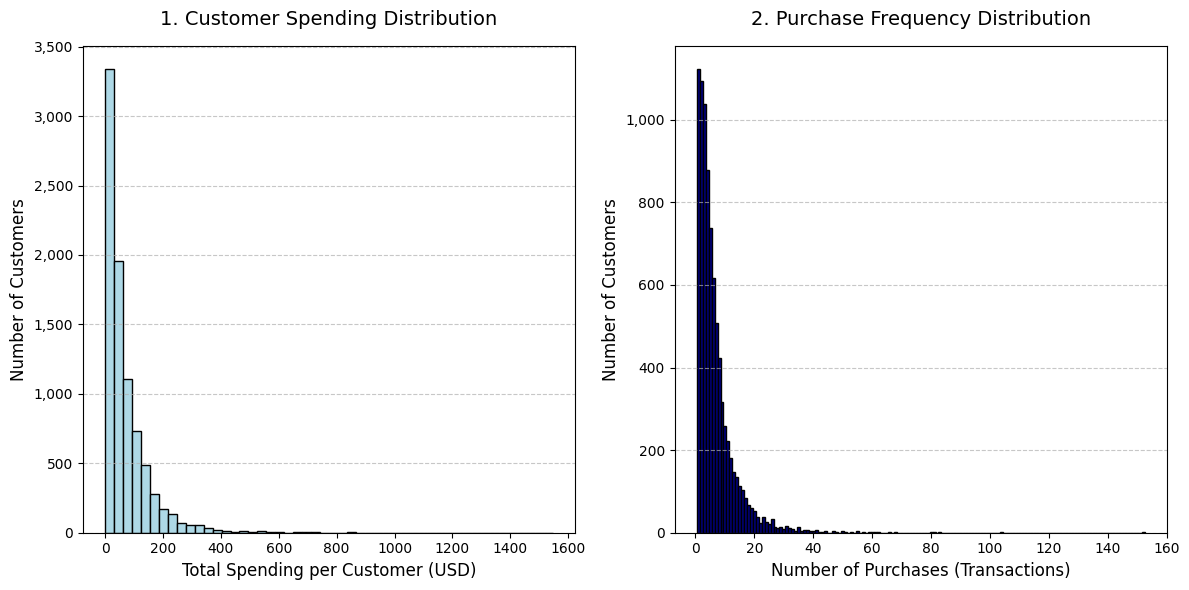

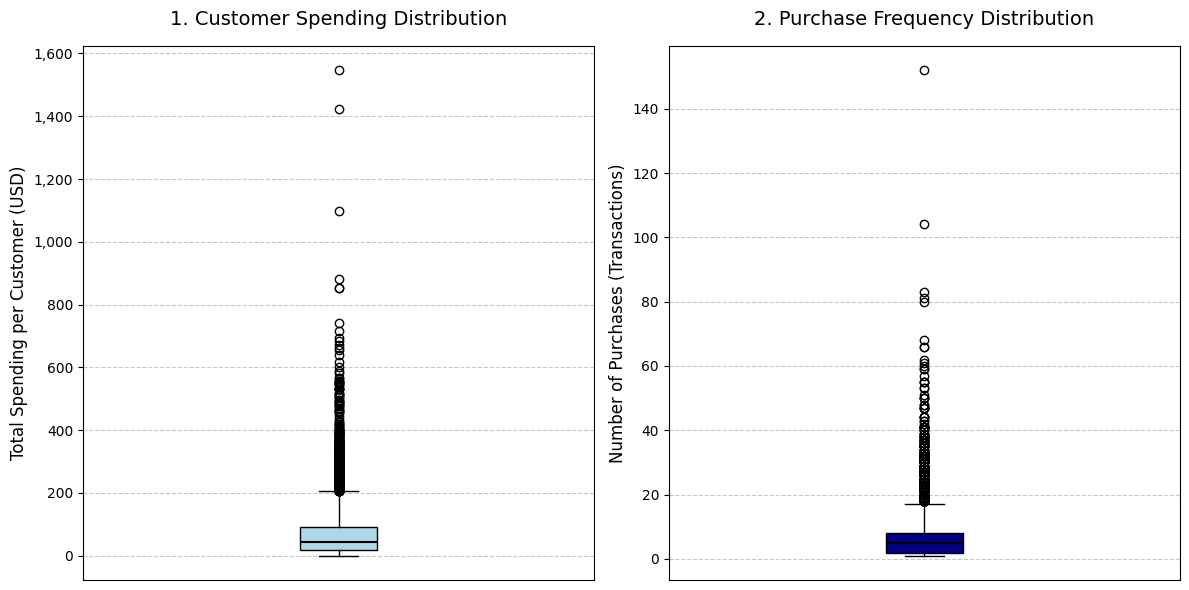

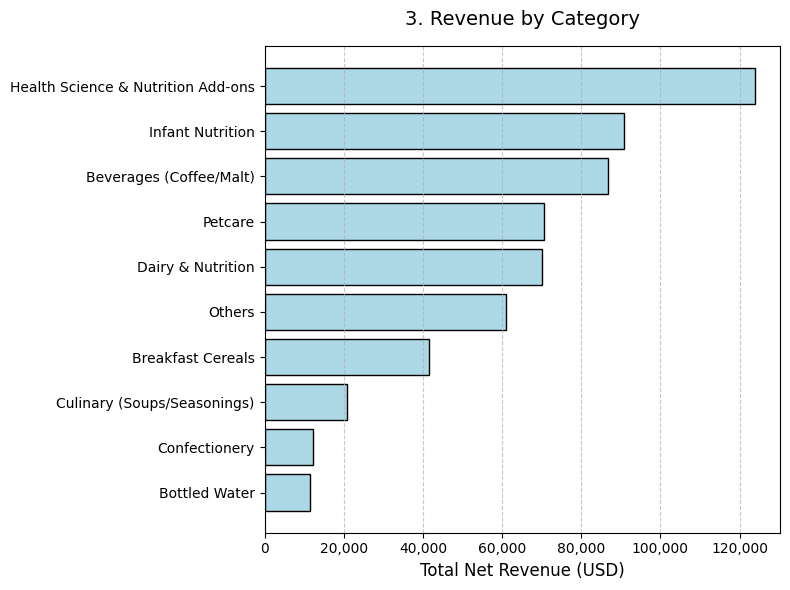

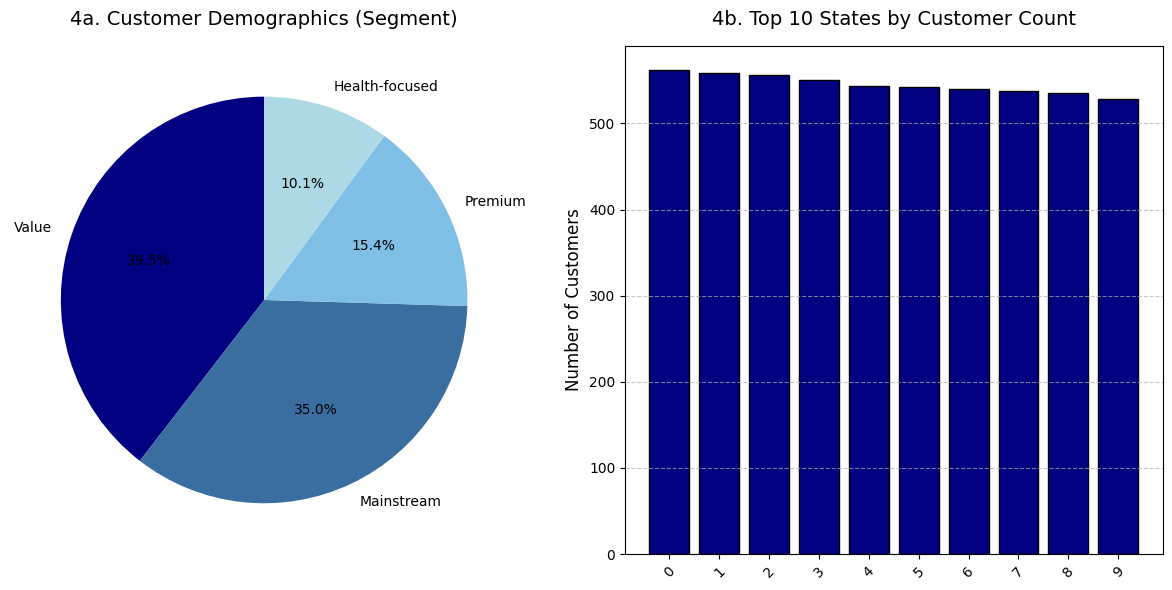

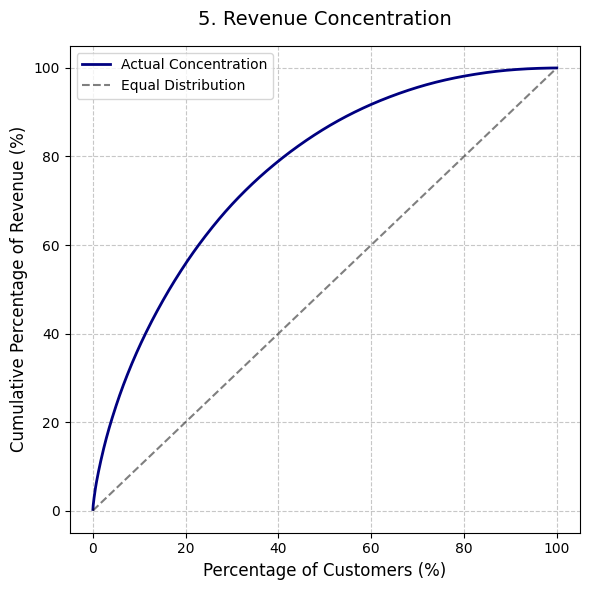

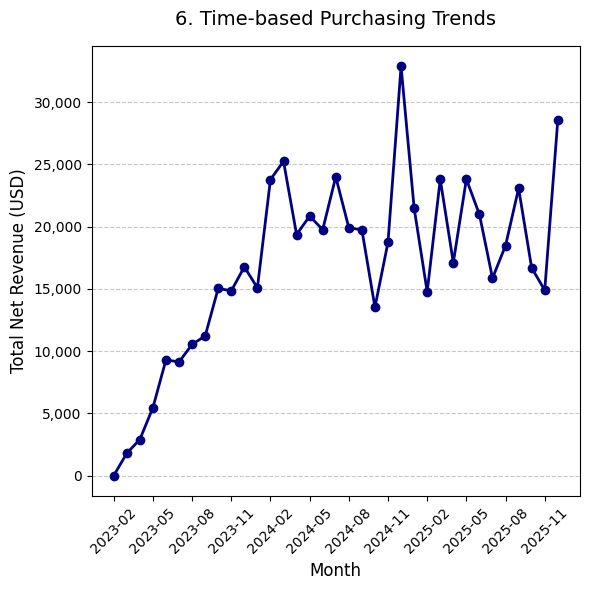

In [ ]:
# Plot all the charts for the EDA
plot_spending_and_frequency(df_orders) 
plot_spending_and_frequency_boxplot(df_orders) 
plot_category(df_items)
plot_demographics(df_items)
plot_concentration(df_orders)
plot_trends(df_orders)

Customer-level aggregation across 8,510 unique customers reveals a strongly right-skewed distribution for both spending and purchase frequency. The mean customer spends $69.27 USD over the observation window with a standard deviation of $82.73, and places on average 6.69 orders with a standard deviation of 7.02. In both cases the standard deviation exceeds the mean, confirming pronounced customer heterogeneity: a large majority of the base clusters at low frequency and low spend, while a thin high-value tail generates a disproportionate share of total revenue.

The Lorenz curve reveals a significant departure from the equal-distribution diagonal, in fact any blanket marketing investment that treats all customers equally ignores the structural inequality embedded in the data.

The top categories by total revenue are Nutrition Adds-ons, Infant Nutrition and Beverages (Coffee/Malt). 
Monthly revenue trends over the 2023–2025 window reveal the temporal purchasing and captures the dominant behavioral pattern.

Demographic distributions were computed on unique customers (de-duplicated at `customer_id` level) to avoid inflating segment counts with repeat-purchase observations. The four self-reported customer types (Mainstream, Value, Premium, and Health-focused) are distributed broadly proportionally across the base. This demographic variable carries no predictive power for CLV tier, which has direct implications for how acquisition and CRM investments should be structured.

## Part C - RFM analysis

In [ ]:
def assign_score(series, n_bins, ascending=True):
    labels = list(range(1, n_bins + 1)) if ascending else list(range(n_bins, 0, -1)) # build the laves if ascending or descending order
    try:
        return pd.qcut(series, q=n_bins, labels=labels, duplicates='drop') #it's preferred a quantile-based binning (equal size)
        # also it drops duplicates to avoid issues with bin edges that are not unique, which can happen with small datasets or skewed distributions like this case
    except ValueError:
        # If qcut fails fall back to equal-width bins.
        return pd.cut(series, bins=n_bins, labels=labels, duplicates='drop')


def calculate_rfm(df_orders: pd.DataFrame) -> pd.DataFrame:

    # Snapshot date: day after last recorded transaction
    df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
    snapshot_date = df_orders['order_date'].max() + pd.Timedelta(days=1)
    print(f"Snapshot date: {snapshot_date.date()}")

    # Aggregate raw RFM metrics at customer level
    rfm = df_orders.groupby('customer_id').agg({
        'order_date': lambda x: (snapshot_date - x.max()).days,
        'order_id': 'count',
        'net_revenue_usd': 'sum'
    }).reset_index()

    # Renaming everything to standard RFM to improve readability
    rfm.rename(columns={
        'order_date': 'Recency',
        'order_id': 'Frequency',
        'net_revenue_usd': 'Monetary'
    }, inplace=True)

    print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

    # Point 3 - Adaptive scoring with 5 bins and handling of potential duplicates in bin edges
    N_BINS = 5
    rfm['R_Score'] = assign_score(rfm['Recency'],   n_bins=N_BINS, ascending=False) # inverted because lower recency is better
    rfm['F_Score'] = assign_score(rfm['Frequency'], n_bins=N_BINS, ascending=True)
    rfm['M_Score'] = assign_score(rfm['Monetary'],  n_bins=N_BINS, ascending=True)

    #transform the scores into integers for easier manipulation and concatenation
    for col in ['R_Score', 'F_Score', 'M_Score']:
        rfm[col] = rfm[col].astype(int)

    # RFM_Segment is a concatenation of the 3 scores, in this way we can extract easily the values of each score for each segment
    rfm['RFM_Segment'] = (
        rfm['R_Score'].astype(str) +
        rfm['F_Score'].astype(str) +
        rfm['M_Score'].astype(str))
    
    # RFM_Score as single summary indicator (1-5 scale)
    rfm['RFM_Score'] = ((rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']) / 3).round(2)
    print(f"\nUnique RFM Segments: {rfm['RFM_Segment'].nunique()} out of {N_BINS**3} possible")

    # Point 4 - Segment Verification and Pruning
    MIN_SIZE = 100 # under 100 observations segments are not statistically representative
    segment_counts = rfm['RFM_Segment'].value_counts()
    small_segments = segment_counts[segment_counts < MIN_SIZE].index #Divide in 2 blocks to have more clarity in the segments
    large_segments = segment_counts[segment_counts >= MIN_SIZE].index

    customers_to_reassign = rfm['RFM_Segment'].isin(small_segments).sum()
    print(f"Segments below {MIN_SIZE} customers: {len(small_segments)}")

    def decode_segment(seg): #separate the R, F and M scores from the segment string to calculate the distance between segments
        return int(seg[0]), int(seg[1]), int(seg[2])

    def find_nearest_segment(small_seg, large_segments):
        """
        Find the nearest segment in `large_segments` to `small_seg` using Euclidean distance
        on decoded (R, F, M) coordinates.

        How does the function do that:
        - Decode small_seg to (r1, f1, m1).
        - Prefer searching only among large segments that share the same R value (r2 == r1).
        This reduces search space and enforces R-matching when possible.
        - If no large segment shares the R value, search all large_segments as a fallback.
        - Compute Euclidean distance between decoded vectors and return the large segment with the smallest distance.
        """
        r1, f1, m1 = decode_segment(small_seg)

        # Restrict to large segments that match the R component to prioritize R-aligned matches.
        same_r = [s for s in large_segments if decode_segment(s)[0] == r1]

        # Use matching pool if available, otherwise fall back to full set.
        search_pool = same_r if same_r else list(large_segments)

        min_dist, nearest = float('inf'), None
        for large_seg in search_pool:
            # Decode candidate large segment
            r2, f2, m2 = decode_segment(large_seg)

            # Euclidean distance in (R,F,M) space
            dist = np.sqrt((r1 - r2) ** 2 + (f1 - f2) ** 2 + (m1 - m2) ** 2)

            # Keep the closest candidate
            if dist < min_dist:
                min_dist, nearest = dist, large_seg

        return nearest

    # Build mapping: for each small segment, find its nearest large segment.
    segment_mapping = {}
    for small_seg in small_segments:
        segment_mapping[small_seg] = find_nearest_segment(small_seg, large_segments)


    # Apply mapping
    rfm['RFM_Segment'] = rfm['RFM_Segment'].replace(segment_mapping)

    print(f"Segments before pruning: {len(large_segments) + len(small_segments)}")
    print(f"Segments after pruning: {rfm['RFM_Segment'].nunique()}")
    print(f"Customers reassigned: {customers_to_reassign}")    
    print(f"\nRFM table successfully generated for {rfm.shape[0]} unique customers.")

    # Output required:
    # 1. Customer-level RFM table
    print("\nCustomer-Level RFM Table (sample)")
    print(rfm[['customer_id', 'Recency', 'Frequency', 'Monetary', 
            'R_Score', 'F_Score', 'M_Score', 'RFM_Segment', 'RFM_Score']].head(5).to_string(index=False))
    
    # 2. Distribution of RFM scores
    print("\nRFM Score Distribution")
    print(rfm['RFM_Score'].describe().round(2))
    print(f"\nCustomers per RFM Score level:")
    print(rfm['RFM_Score'].value_counts().sort_index())

    # Top 10 customers by RFM score
    print("\nTop 10 Customers by RFM Score")
    top10 = (rfm[['customer_id', 'Recency', 'Frequency', 'Monetary', 
                'RFM_Segment', 'RFM_Score']]
            .sort_values(by=['RFM_Score', 'RFM_Segment'], ascending=[False, False])
            .head(10)
            .to_string(index=False))
    print(top10)
    return rfm


In [11]:
rfm_table = calculate_rfm(df_orders) # Calculate RFM scores for each customer

Snapshot date: 2025-12-29
       Recency  Frequency  Monetary
count  8510.00    8510.00   8510.00
mean    238.60       6.69     69.27
std     233.34       7.02     82.73
min       1.00       1.00      0.00
25%      51.00       2.00     17.38
50%     161.00       5.00     44.17
75%     361.00       8.00     92.45
max    1018.00     152.00   1546.92

Unique RFM Segments: 111 out of 125 possible
Segments below 100 customers: 83
Segments before pruning: 111
Segments after pruning: 28
Customers reassigned: 2985

RFM table successfully generated for 8510 unique customers.

Customer-Level RFM Table (sample)
customer_id  Recency  Frequency   Monetary  R_Score  F_Score  M_Score RFM_Segment  RFM_Score
 CUST000001        7          1  61.836867        5        1        4         544       3.33
 CUST000003      291          6  32.554096        2        3        3         233       2.67
 CUST000005       41         26 117.222530        4        5        5         455       4.67
 CUST000006       95

The RFM analysis was conducted following a five-step methodology designed to ensure both statistical robustness and business interpretability.

**Step 1: Snapshot Date**:
A reference date was defined as the day after the last recorded transaction in the dataset (2025-12-29). This ensured that every customer has a Recency value of at least 1 day, avoiding zero-division issues in downstream CLV calculations and preserving the interpretability of recency as a strictly positive elapsed-time measure.

**Step 2: Raw Metric Aggregation**:
Three core metrics were computed at the customer level from `df_orders`:
- **Recency**: number of days elapsed since the customer's last purchase relative to the snapshot date
- **Frequency**: total number of orders placed across the 2023–2025 observation window
- **Monetary**: total net revenue (USD) generated over the same window

The resulting RFM table covers 8,510 unique customers. The high standard deviations relative to the means across all three dimensions confirm the pronounced customer heterogeneity that motivates the probabilistic framework in Part E.

**Step 3: Adaptive Scoring**:
Each metric was discretised into 5 ordinal score levels (1–5) using quantile-based binning, selected over equal-width alternatives because the right-skewed distributions of Frequency and Monetary would concentrate the majority of customers into the lowest two equal-width bins, producing scoring distributions with near-zero discrimination power in the mid-range. So, quintile binning guaranteed that each score level contained approximately 20% of the customer population, ensuring every score from 1 to 5 is both statistically populated and operationally actionable. 
Because many customers share identical low transaction counts, bin boundaries are not always unique, so dropping duplicate edges reduced the effective number of bins gracefully without distorting the underlying rank ordering. 
Recency scoring is intentionally inverted (lower elapsed days → higher score).

**Step 4: Segment Verification and Pruning**:
The three individual scores were combined into a three-character RFM_Segment identifier (e.g. '514' = R:5, F:1, M:4) and a continuous RFM_Score summary indicator computed as the unweighted arithmetic mean of the three scores on a 1–5 scale. Out of 125 theoretically possible segments (5³), 111 were observed in the data. Of these, 83 contained fewer than 100 customers and were deemed statistically insufficient for reliable segment profiling, a segment of 5–10 customers cannot support stable mean estimates or representative characterisation.

**Step 5: Constrained 3D Euclidean Reassignment**:
Customers in sparse segments were reassigned to the nearest large segment (n ≥ 100) using a 3D Euclidean distance approach in (R, F, M) score space. The constraint requires the target segment to share the same R score as the original. This is done because in the empirical marketing literature on non-contractual purchasing, Recency is the strongest predictor of repurchase probability, because temporal distance from the last purchase is the dominant signal of latent customer activity. Preserving R-score identity during reassignment prevents recently active customers from being merged with long-inactive customers, which would systematically misallocate retention resources. If no large segment with the same R score exists, the search expands to all large segments as a fallback. Following pruning, the final segmentation comprises 28 meaningful RFM segments covering all 8,510 customers, with 2,985 customers (35.1%) successfully reassigned.

## Part D – Customer Lifetime Value Analysis

In [12]:

def calculate_clv(rfm: pd.DataFrame, df_orders: pd.DataFrame) -> pd.DataFrame:

    # Churn Rate
    CHURN_THRESHOLD = 90  # days
    total_customers = len(rfm)
    churned_customers = (rfm['Recency'] > CHURN_THRESHOLD).sum()
    churn_rate = churned_customers / total_customers # calculate churn rate

    print()
    print(f"Total customers: {total_customers:,}")
    print(f"Churned customers: {churned_customers:,} (Recency > {CHURN_THRESHOLD} days)")
    print(f"Churn Rate: {churn_rate:.4f} ({churn_rate*100:.1f}%)")

    # Join signup_date via customer_id
    signup = df_orders[['customer_id', 'signup_date']].drop_duplicates('customer_id')
    clv = rfm.merge(signup, on='customer_id', how='left')

    # APV: Average Purchase Value per customer
    clv['APV'] = clv['Monetary'] / clv['Frequency']

    # PF: Purchase Frequency normalized by active days
    snapshot_date = pd.to_datetime(df_orders['order_date']).max() + pd.Timedelta(days=1)
    clv['signup_date'] = pd.to_datetime(clv['signup_date'])
    clv['active_months'] = (snapshot_date - clv['signup_date']).dt.days / 30 
    #frequency normalized by the number of months since signup to account for different customer lifetimes
    clv['PF'] = clv['Frequency'] / clv['active_months']

    print()
    # CLV per customer
    clv['CLV'] = (clv['APV'] * clv['PF']) / churn_rate
    clv.rename(columns={
        'APV': 'APV ($)',
        'PF': 'PF (purchases/month)',
        'CLV': 'CLV ($/month)'
    }, inplace=True)
    
    print(f"\nAll Customers CLV")
    print(clv[['APV ($)', 'PF (purchases/month)', 'CLV ($/month)']].describe().round(3))

    # Active customers only (not churned)
    clv_active = clv[clv['Recency'] <= 90].copy()

    print(f"\nActive Customers CLV")
    print(f"Active customers: {len(clv_active):,} ({len(clv_active)/len(clv)*100:.1f}% of total)")
    print(clv_active[['APV ($)', 'PF (purchases/month)', 'CLV ($/month)']].describe().round(3))

    print("\nTop 20 Customers by CLV")
    top20 = (clv[['customer_id', 'Recency', 'Frequency', 'Monetary',
                'APV ($)', 'PF (purchases/month)', 'CLV ($/month)']]
            .sort_values('CLV ($/month)', ascending=False)
            .head(20)
            .to_string(index=False))
    print(top20)

    return clv



def plot_clv_distribution(clv: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    ax.hist(clv['CLV ($/month)'], bins=40, color="#000080", edgecolor='black')
    ax.set_title('CLV Distribution', fontsize=14, pad=15)
    ax.set_xlabel('CLV ($/month)', fontsize=12)
    ax.set_ylabel('Number of Customers', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    
    plt.tight_layout()
    plt.savefig('plots/clv_distribution.jpg', dpi=300)
    plt.show()



Total customers: 8,510
Churned customers: 5,356 (Recency > 90 days)
Churn Rate: 0.6294 (62.9%)


All Customers CLV
        APV ($)  PF (purchases/month)  CLV ($/month)
count  8510.000              8510.000       8510.000
mean     10.341                 0.234          3.850
std       8.112                 0.239          4.513
min       0.000                 0.029          0.000
25%       5.473                 0.086          0.973
50%       8.820                 0.165          2.450
75%      12.811                 0.296          5.209
max     153.084                 4.755         78.904

Active Customers CLV
Active customers: 3,154 (37.1% of total)
        APV ($)  PF (purchases/month)  CLV ($/month)
count  3154.000              3154.000       3154.000
mean     10.564                 0.366          6.105
std       6.299                 0.307          5.841
min       0.079                 0.029          0.004
25%       6.692                 0.172          2.251
50%       9.564           

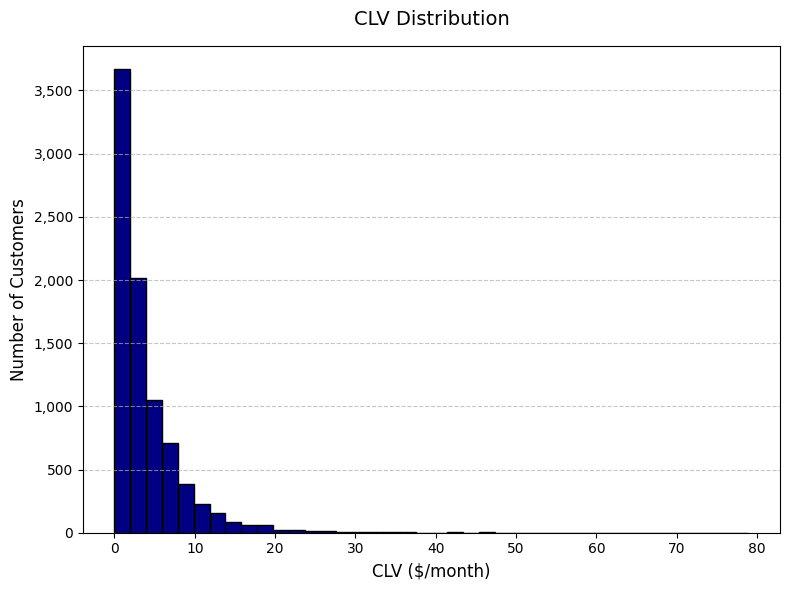

In [13]:
clv_table = calculate_clv(rfm_table, df_orders)
plot_clv_distribution(clv_table) # Plot the distribution of CLV across customers to understand the range and identify high-value customers

The descriptive CLV was estimated using a simplified three-component framework:
CLV ($/month) = (APV × PF) / Churn Rate

All components are computed at the individual customer level using the RFM-aggregated dataset, ensuring structural consistency with the previous part. This formula is the approximation of the discounted cash flow CLV model under the assumption of a stationary purchase process. 
Three structural assumptions are embedded: 
1. each customer's APV and PF are expected to remain constant over the prediction horizon; 
2. the aggregate churn rate is applied as a population-level denominator rather than an individual-level probability, which structurally underestimates the CLV of behaviorally loyal customers; 
3. the output is a monthly flow value ($/month) making it non-comparable with the BG/NBD output in the next part, without explicitly applying a time horizon multiplier.

The first component of the formula was the **Average Purchase Value (APV)** that was computed at the customer level as `APV_i = Monetary_i / Frequency_i` (USD), capturing each individual's average spend per transaction rather than a dataset-level aggregate.

Then the **Purchase Frequency (PF)** was normalised over each customer's individual active lifetime, defined as the period between their `signup_date` and the snapshot date (2025-12-29), divided by 30 to produce purchases per month. This individual-tenure normalisation captures each customer's intrinsic purchase rate while accounting for the structural differences in tenure across the base: a customer who joined in January 2023 and one who joined in October 2025 should not have their transaction counts compared without tenure adjustment.

At the end the **Churn Rate**, where customers were classified as churned if their Recency exceeded 90 days. Of the 8,510 unique customers, 5,356 (62.9%) were identified as churned, yielding an aggregate Churn Rate of 0.6294. This is a structurally elevated rate that warrants interpretation beyond its use as a formula input. Two competing explanations carry distinct strategic implications: under a behavioral churn interpretation, a large fraction of the base genuinely exited after a limited number of purchases, suggesting the retailer's acquisition model depends disproportionately on one-time or promotional stimuli. Under a threshold sensitivity interpretation, 90 days may be too conservative for categories such as Culinary/Soups with longer natural replenishment cycles, in which case a category-stratified threshold would reclassify a meaningful share of 'churned' customers as infrequent-but-loyal and materially lower the aggregate rate. The churn rate of 0.6294 is applied as a shared denominator across all individual CLV calculations, a deliberate simplification partially mitigated in Part E, where the BG/NBD model estimates individual-level survival probabilities from the full joint distribution of recency and tenure.

A subset of customers presented Monetary = 0 due to the `.clip(lower=0)` applied during data preparation. These customers show CLV = 0 and are retained in the dataset for completeness but should be interpreted with caution.

**Results**
- Full dataset (8,510 customers): mean CLV = $3.85/month, max = $78.90/month
- Active customers only (3,154 customers, 37.1% of base): mean CLV = $6.11/month

The 59% CLV premium of active over all customers confirms that Recency is a critical discriminator of realised value — consistent with its primacy in the RFM scoring framework and the BG/NBD model in Part E.

The top 20 customers by CLV are all active (Recency < 90 days) and share a consistent profile: high purchase frequency (39–152 orders), moderate-to-high APV ($9–16), and tenure spanning the full observation window. The highest-value customer (CUST002744) achieves $78.90/month through an optimal combination of frequency (104 orders) and spending consistency ($13.67 APV), rather than extreme individual transaction size.

## Part E - Predict CLV

In [ ]:
def predict_clv(df_orders: pd.DataFrame) -> pd.DataFrame:

    df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
    snapshot_date = df_orders['order_date'].max() + pd.Timedelta(days=1) #select the last day +1 of the dataset as it done before
    calibration_end = pd.Timestamp('2024-12-31') #split the dataset in 2 periods (train 2 years + test 1 year)

    # Transform the dataframe into the format required by the lifetimes library
    bgf_summary = summary_data_from_transaction_data(
        df_orders,
        customer_id_col='customer_id',
        datetime_col='order_date',
        monetary_value_col='gross_revenue_usd',
        observation_period_end=snapshot_date,
        freq='W' #weekly frequency because the month time period is not supported by the libraries (pandas + lifetimes)
    )

    print(f"\nBG/NBD Summary")
    print(bgf_summary.describe().round(3)) # show the summary of the data after the transformation

    # Filter for repeat purchasers for Gamma-Gamma (requires frequency > 0) and purchases without the discount
    # In fact as said before, some discounts are <0 because are calculated on the unit price, not the full order.
    gg_summary = bgf_summary[
        (bgf_summary['frequency'] > 0) & 
        (bgf_summary['monetary_value'] > 0)] # customers with at least 1 repeated purchase

    # Fit BetaGeo model (for frequency/recency)
    bgf = BetaGeoFitter(penalizer_coef=0.01) #it's the model BG/NDB 
    bgf.fit(
        bgf_summary['frequency'],
        bgf_summary['recency'],
        bgf_summary['T']
    )
    print(f"\nBetaGeo Model") # show the summary of the model fit, including parameter estimates and statistical significance
    print(bgf.summary)

    # Fit GammaGamma model (for monetary value)
    ggf = GammaGammaFitter(penalizer_coef=0.01)
    ggf.fit(
        gg_summary['frequency'],
        gg_summary['monetary_value']
    )
    print(f"\nGammaGamma Model") # same as before but with gamma  model
    print(ggf.summary)

    # Predict CLV over the 52 weeks of the year
    bgf_summary['predicted_clv'] = ggf.customer_lifetime_value( #combine the 2 models to predict the CLTV
        bgf,
        bgf_summary['frequency'],
        bgf_summary['recency'],
        bgf_summary['T'],
        bgf_summary['monetary_value'],
        time=52,
        freq='W',
        discount_rate=0.01 #applied to reflect the time value of money, used in finance evaluations
    )

    # Validation on holdout period (our last year of data)
    summary_cal_holdout = calibration_and_holdout_data(
        df_orders,
        customer_id_col='customer_id',
        datetime_col='order_date',
        monetary_value_col='gross_revenue_usd',
        calibration_period_end=calibration_end, #divide by calibration and holdout with the dates we have chosen before
        observation_period_end=snapshot_date,
        freq='W'
    )

    # Predict frequency during holdout period
    summary_cal_holdout['predicted_frequency'] = bgf.predict(
        t=summary_cal_holdout['duration_holdout'],
        frequency=summary_cal_holdout['frequency_cal'],
        recency=summary_cal_holdout['recency_cal'],
        T=summary_cal_holdout['T_cal']
    )

    actual = summary_cal_holdout['frequency_holdout']
    predicted = summary_cal_holdout['predicted_frequency']

    # Remove model-generated NaN values before computing metrics.
    # We know that there are NOT missing values from the original dataset (verified in Part A),
    # but numerical instabilities produced by the BG/NBD model for customers with insufficient transaction history in the calibration or holdout period,
    # or zero monetary value causing log(0) in the GammaGamma likelihood.
    mask = ~(predicted.isna() | actual.isna())
    actual_clean = actual[mask]
    predicted_clean = predicted[mask]
    
    print(f"Customers excluded due to NaN: {(~mask).sum()}")

    # Evaluation metrics for frequency prediction
    rmse = np.sqrt(mean_squared_error(actual_clean, predicted_clean))
    mae = mean_absolute_error(actual_clean, predicted_clean)
    r2 = r2_score(actual_clean, predicted_clean)

    print(f"\nModel Evaluation")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE: {mae:.3f}")
    print(f"R²: {r2:.3f}")

    print(f"\nPredicted CLV Summary")
    print(bgf_summary['predicted_clv'].describe().round(3))

    print(f"\nTop 20 Customers by Predicted CLV")
    top20_predicted = (bgf_summary[['frequency', 'recency', 'T', 
                                     'monetary_value', 'predicted_clv']]
                      .sort_values('predicted_clv', ascending=False)
                      .head(20)
                      .round(2)
                      .to_string())
    print(top20_predicted)

    return bgf_summary

def plot_predicted_clv(bgf_summary: pd.DataFrame) -> None:

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))

    # Left: full distribution
    axes[0].hist(bgf_summary['predicted_clv'].dropna(), 
                 bins=40, color='#ADD8E6', edgecolor='black')
    axes[0].set_title('Predicted CLV Distribution (All Customers)')
    axes[0].set_xlabel('Predicted CLV ($)')
    axes[0].set_ylabel('Number of Customers')
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

    # Right: zoomed (exclude top 1% outliers for readability)
    p99 = bgf_summary['predicted_clv'].quantile(0.99)
    axes[1].hist(bgf_summary[bgf_summary['predicted_clv'] <= p99]['predicted_clv'].dropna(),
                 bins=40, color="#ADD8E6", edgecolor='black')
    axes[1].set_title('Predicted CLV Distribution (Excluding Top 1%)')
    axes[1].set_xlabel('Predicted CLV ($)')
    axes[1].set_ylabel('Number of Customers')
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig('plots/predicted_clv_distribution.jpg', dpi=300)
    plt.show()


BG/NBD Summary
       frequency   recency         T  monetary_value
count   8510.000  8510.000  8510.000        8510.000
mean       5.323    66.268   100.790           9.571
std        6.028    41.794    28.796           8.879
min        0.000     0.000     1.000           0.000
25%        1.000    30.000    86.000           3.731
50%        4.000    73.000   105.000           8.187
75%        7.000   100.000   122.000          13.037
max       86.000   147.000   148.000         150.343

BetaGeo Model
            coef  se(coef)  lower 95% bound  upper 95% bound
r       1.336993  0.025312         1.287382         1.386605
alpha  23.898424  0.522799        22.873738        24.923110
a       0.050056  0.003739         0.042727         0.057385
b       0.772116  0.048490         0.677075         0.867156

GammaGamma Model
       coef  se(coef)  lower 95% bound  upper 95% bound
p  2.952830  0.045750         2.863160         3.042501
q  1.398651  0.021243         1.357014         1.440287
v

c:\Users\3003f\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\3003f\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Customers excluded due to NaN: 1788

Model Evaluation
RMSE: 2.345
MAE: 1.783
R²: 0.426

Predicted CLV Summary
count    7369.000
mean      102.605
std       105.075
min         0.001
25%        33.025
50%        70.925
75%       139.281
max      1711.509
Name: predicted_clv, dtype: float64

Top 20 Customers by Predicted CLV
             frequency  recency      T  monetary_value  predicted_clv
customer_id                                                          
CUST002744        66.0    119.0  122.0           21.74        1711.51
CUST000058        86.0    135.0  137.0           18.13        1684.75
CUST002370        58.0    140.0  141.0           18.96        1169.04
CUST003831        52.0    124.0  125.0           16.57        1015.68
CUST003565        49.0    126.0  128.0           17.88        1012.86
CUST006740        44.0    100.0  103.0           16.38         996.14
CUST007944        33.0    106.0  107.0           20.72         926.07
CUST008014        64.0    133.0  138.0       

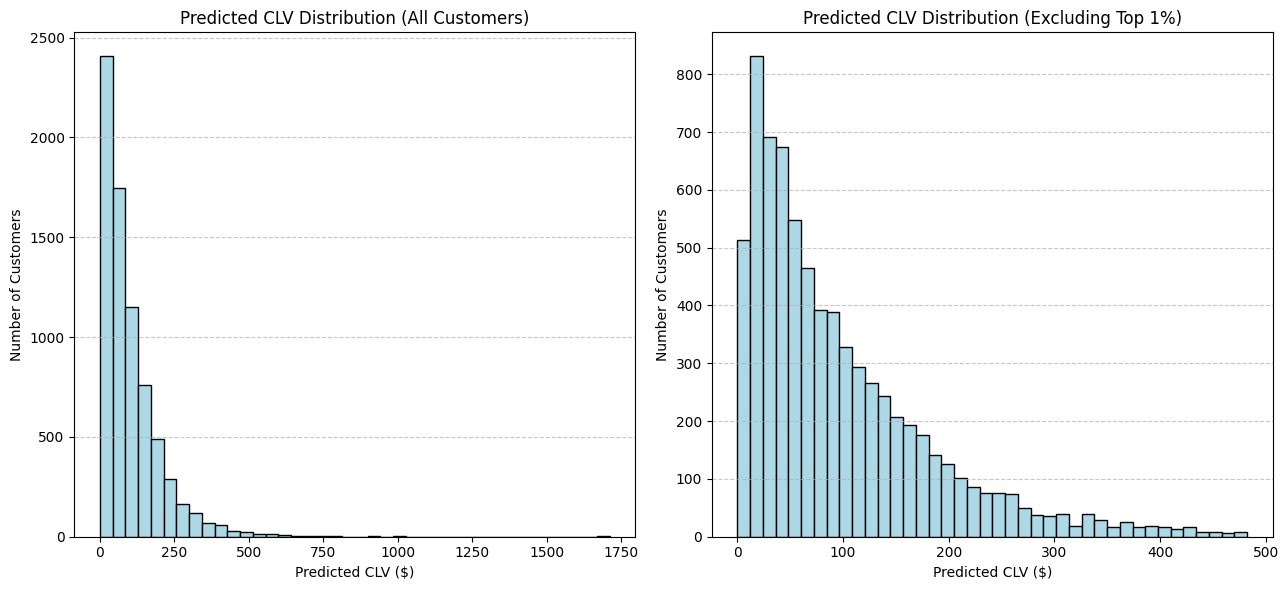

In [15]:
bgf_summary = predict_clv(df_orders)
plot_predicted_clv(bgf_summary) # Plot the distribution of predicted CLV from the BG/NBD model to visualize the expected customer value over time

The BG/NBD combined with the Gamma-Gamma model was selected as the predictive framework for three reasons: 
1. the dataset represents a non-contractual FMCG context where customers purchase at any time without a fixed subscription or contract 
2. the three-year observation window (2023–2025) provides the parameter estimation depth required by the BG/NBD likelihood; 
3. the customer base shows pronounced heterogeneity consistent with the Gamma-distributed heterogeneity assumptions embedded in both model components.

All time units were expressed in weeks due to a compatibility constraint between lifetimes and pandas, which does not support monthly frequency in this context.

The BetaGeo model captured two metrics simultaneously: how often a customer buys, and whether they have stopped buying altogether. A small penalisation coefficient (0.01) was added to prevent the handful of very high-frequency customers from distorting the estimates. The purchase-rate parameters (r=1.34, alpha=23.90) imply ~0.056 transactions per customer per week, consistent with the observed mean of 6.7 orders over 148 weeks. The dropout parameters (a=0.05, b=0.77) indicate that most customers have a low probability of churning after any given purchase — once engaged, they tend to stay.

The Gamma-Gamma model estimates how much a customer is likely to spend per transaction. It was fitted only on customers with at least one repeat purchase, since a single transaction is insufficient to estimate individual spending patterns. The parameters (p=2.95, q=1.40, v=2.99) are tightly estimated, indicating a stable spending distribution across the base.

Performance was assessed using a temporal train/test split — the methodologically correct validation approach for time-series transaction data, as random splits would leak future information into the calibration period:
- Calibration period: January 2023 – December 2024 (24 months)
- Holdout period: January 2025 – December 2025 (12 months) 
using a monthly discount rate of 1%.

The results show a MAE of 1.783 meaning that, on average, frequency predictions deviate by 1.78 transactions. Then RMSE 2.345 confirms a heavy right tail in prediction errors: the model systematically underestimates frequency for the top-decile high-frequency customers.
At the last metric, the R²=0.426 show that the model explains 42.6% of variance in holdout purchase frequency. 
The published BG/NBD applications on comparable non-contractual FMCG panels report R² in the 0.35–0.55 range (Fader, Hardie & Lee, 2005), place this result within the expected performance envelope.

The top 20 customers by predicted CLV are consistent with the descriptive ranking from Part D, with CUST002744 ($1,711.51) and CUST000058 ($1,684.75) leading both lists. All top 20 customers exhibit recency values close to their total customer age T (recency ≈ T), confirming they remained active throughout the entire observation window and are assigned high survival probabilities by the BG/NBD model.

## Part F – Customer Segmentation 

In [18]:
def segment_customers(clv: pd.DataFrame, df_items: pd.DataFrame) -> pd.DataFrame:

    # assign segments based on CLV
    df_segments = clv[['customer_id', 'Recency', 'Frequency', 'Monetary',
                        'APV ($)', 'PF (purchases/month)', 'CLV ($/month)']].copy()

    df_segments['Segment'] = pd.qcut(
        df_segments['CLV ($/month)'],
        q=[0, 0.20, 0.50, 0.80, 1.0],
        labels=['Bronze', 'Silver', 'Gold', 'Platinum']
    ) #divide each segment based on the quantities required

    order = ['Platinum','Gold','Silver','Bronze']
    df_segments['Segment'] = pd.Categorical(df_segments['Segment'], categories=order, ordered=True)
    df_segments = df_segments.sort_values('Segment')  # Platinum first

    # Segment Summary Table with average metrics per segment
    summary = df_segments.groupby('Segment').agg(
        Customers=('customer_id', 'count'),
        Avg_Recency=('Recency', 'mean'),
        Avg_Frequency=('Frequency', 'mean'),
        Avg_Monetary=('Monetary', 'mean'),
        Avg_APV=('APV ($)', 'mean'),
        Avg_PF=('PF (purchases/month)', 'mean'),
        Avg_CLV=('CLV ($/month)', 'mean')
    ).round(2) # calculate the average of each metric for each segment to have a summary table of the segments

    print("\nSegment summary table")
    print(summary.to_string())

    # Join with df_items for demographics and product preferences
    items_customer = df_items[['customer_id', 'segment', 'city',
                                'state', 'category_name', 'brand']].copy()
    items_customer.rename(columns={'segment': 'customer_type'}, inplace=True)
    df_segments = df_segments.merge(items_customer, on='customer_id', how='left')

    # Demographics: segment distribution per CLV segment
    print("\nCustomer demographics by segment")
    demo = df_segments.groupby(['Segment', 'customer_type']).size().unstack(fill_value=0)
    print(demo.to_string())

    # Product preferences: top category per CLV segment as a similar plot created before, but this time with the segment as categories
    print("\nProduct preferences by segment")
    prefs = (df_segments.groupby(['Segment', 'category_name'])
             .size()
             .reset_index(name='item_occurrences')
             .sort_values(['Segment', 'item_occurrences'], ascending=[True, False])
             .groupby('Segment')
             .head(3))
    print(prefs.to_string(index=False))

    return df_segments

def plot_segments(df_segments: pd.DataFrame) -> None:

    segment_order = ['Bronze', 'Silver', 'Gold', 'Platinum']
    colors = ['#CD7F32', '#C0C0C0', '#FFD700', '#E5E4E2']

    #  CLV + Customer Type
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Average CLV by Segment
    clv_means = df_segments.groupby('Segment')['CLV ($/month)'].mean().reindex(segment_order)
    axes[0].bar(clv_means.index, clv_means.values, color=colors, edgecolor='black')
    axes[0].set_title('Average CLV by Segment', fontsize=13, pad=10)
    axes[0].set_xlabel('Segment')
    axes[0].set_ylabel('Avg CLV ($/month)')
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)
    for i, v in enumerate(clv_means.values):
        axes[0].text(i, v + 0.1, f'${v:.2f}', ha='center', fontsize=9)

    # Plot 2: Customer Type Distribution by Segment
    demo = (df_segments.groupby(['Segment', 'customer_type'])
            .size()
            .unstack(fill_value=0)
            .reindex(segment_order))
    demo_pct = demo.div(demo.sum(axis=1), axis=0) * 100
    demo_pct.plot(kind='bar', stacked=True, ax=axes[1],
                  color=['#000080', '#3b6ea0',  '#7fbfe6','#ADD8E6'], edgecolor='black')
    axes[1].set_title('Customer Type Distribution by Segment', fontsize=13, pad=10)
    axes[1].set_xlabel('Segment')
    axes[1].set_ylabel('% of Customers')
    axes[1].legend(title='Customer Type', bbox_to_anchor=(1.0, 1.0))
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.savefig('plots/segment_clv_demographics.jpg', dpi=300, bbox_inches='tight')
    plt.show()


def heatmap_segments(df_segments: pd.DataFrame) -> None:
    # Product Category Heatmap
    segment_order = ['Bronze', 'Silver', 'Gold', 'Platinum']
    fig, ax = plt.subplots(figsize=(8, 7))

    cat_segment = (df_segments.groupby(['Segment', 'category_name'])
                .size()
                .unstack(fill_value=0)
                .reindex(segment_order))
    cat_pct = cat_segment.div(cat_segment.sum(axis=1), axis=0) * 100


    sns.heatmap(cat_pct, ax=ax, 
                cmap = sns.blend_palette(["white", "lightblue", "navy"], as_cmap=True),
                annot=True, fmt='.1f', linewidths=0.5,
                annot_kws={'fontsize': 8}, cbar_kws={'shrink': 0.8})
    ax.set_title('Product Category Mix by Segment (%)', fontsize=13, pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('Segment')

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.20)
    plt.savefig('plots/segment_heatmap.jpg', dpi=300, bbox_inches='tight')
    plt.show()



Segment summary table
          Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Avg_APV  Avg_PF  Avg_CLV
Segment                                                                                
Platinum       1702        90.74          15.55        191.86    14.78    0.54    10.69
Gold           2553       171.14           6.92         71.08    12.78    0.24     3.94
Silver         2553       274.56           3.85         27.60     9.09    0.13     1.53
Bronze         1702       433.69           1.77          6.50     4.11    0.06     0.36

Customer demographics by segment
customer_type  Health-focused  Mainstream  Premium  Value
Segment                                                  
Platinum                 3102       10304     6325   9632
Gold                     2113        6998     3025   7365
Silver                    991        3889     1537   4324
Bronze                    359        1066      435   1302

Product preferences by segment
 Segment               category_nam

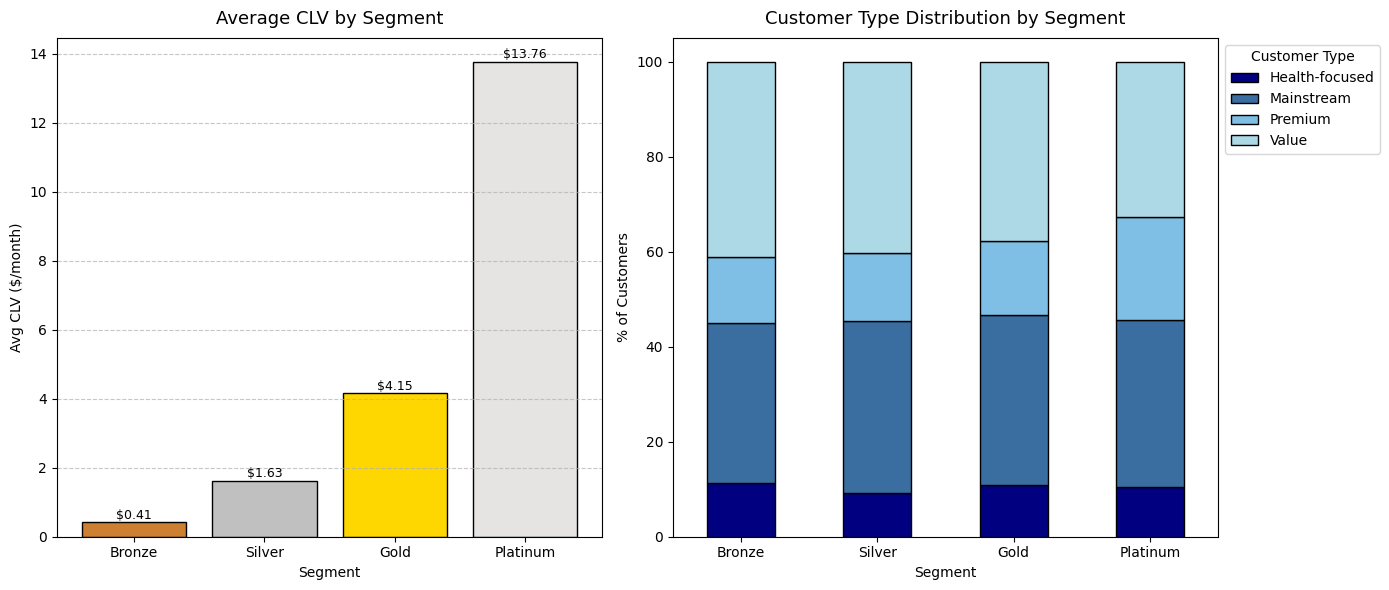

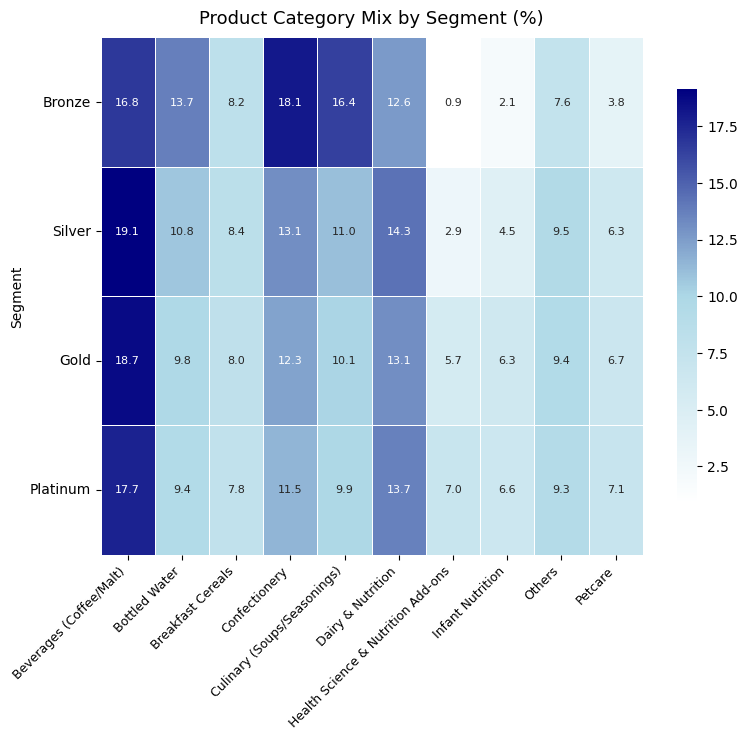

In [19]:
df_segments = segment_customers(clv_table, df_items)
plot_segments(df_segments) # Plot the characteristics of each customer segment to understand their demographics and preferences
heatmap_segments(df_segments) # Plot a heatmap of product category preferences by segment to identify which segments prefer which categories

Customer segmentation was performed using the descriptive CLV estimates, that captures realised customer behaviour over the entire observed period and provides a stable, fully interpretable basis for tier assignment without relying on model assumptions about future purchasing patterns. The predicted CLV is the appropriate tool for forward-looking resource allocation; the descriptive CLV is the appropriate basis for characterising who customers already are.

Customers were divided into four tiers using quantile-based segmentation applied to CLV ($/month), with boundaries at the 20th, 50th, and 80th percentiles:
- **Platinum**: top 20% (CLV above the 80th percentile) with 1,702 customers
- **Gold**: next 30% (50th–80th percentile) with 2,553 customers
- **Silver**: next 30% (20th–50th percentile) with 2,553 customers
- **Bronze**: bottom 20% (below the 20th percentile) with 1,702 customers

So the specific profiles characteristics are the following:
1. *Platinum customers (Avg CLV: $10.69/month)* are the most valuable and most recently active tier. They average 15.55 transactions with a total monetary value of $191.86 and a purchase frequency of 0.54 purchases/month (nearly double that of Gold customers). Their average APV of $14.78 is the highest across all tiers, indicating habitual buying and consistently larger basket sizes. Their average recency of 90.74 days places them exactly at the churn boundary defined in Part D, signalling that even within this elite group a non-trivial share of customers may be at imminent risk of lapsing and warrant proactive retention effort.

2. *Gold customers (Avg CLV: $3.94/month)* customers represent a stable mid-to-high value tier with the highest upgrade potential in the base. They transact roughly 6.92 times on average with a monetary value of $71.08 and an APV of $12.78. Their average recency of 171 days indicates moderate but declining engagement. The gap between Gold and Platinum is driven primarily by frequency (6.92 vs. 15.55 transactions) rather than APV (only a 15% difference). That means that interventions that increase visit cadence are more efficient than those focused on raising basket size.

3. *Silver customers (Avg CLV: $1.53/month)* show lower engagement across all metrics. With an average recency of 274.56 days, only 3.85 transactions, and an APV of $9.09, they appear to be occasional or seasonal buyers who have not developed a consistent purchasing habit. Their purchase frequency of 0.13 purchases/month suggests interactions spaced several months apart, which in a CLV framework translates to very limited revenue contribution per unit time. Under the 90-day churn threshold, the majority of Silver customers would be classified as churned.

4. *Bronze customers (Avg CLV: $0.36/month)* are largely dormant. An average recency of 433.69 days indicates most have not purchased in well over a year, and their average of only 1.77 transactions confirms that the majority interacted with the retailer on at most one or two occasions. Their APV of $4.11 is the lowest across all tiers. Under the 90-day churn definition, virtually all Bronze customers would be classified as churned.


The customer type distribution is broadly proportional across all four CLV tiers. Premium-labeled customers appear in Bronze and Silver at rates similar to their share in Platinum, confirming that the demographic profile captured at acquisition is orthogonal to long-run behavioural value. This invalidates a common commercial practice in FMCG where marketing budgets are allocated by declared customer type at registration: behavioral RFM signals (recency and frequency) are substantially more discriminating for resource allocation than any acquisition-time demographic label. CRM system design and loyalty programme eligibility should be driven by behavioural criteria, not demographic ones.

Product preferences are strikingly stable across Platinum, Gold, and Silver: Beverages (Coffee/Malt), Dairy & Nutrition, and Confectionery consistently rank as the top three categories. Bronze customers show a marginal divergence, with Culinary (Soups/Seasonings) replacing Dairy & Nutrition in third position. This possibly reflect a different purchase occasion profile among infrequent buyers. The absence of strong category differentiation across value tiers implies that blanket category promotions will not differentially activate high-value customers, and that retention strategies should prioritise engagement frequency over category-specific targeting.


## PART G - Managerial Recommendations


### 1. Customer Retention
The RFM analysis identified 8,510 unique customers, of whom 5,356 (62.9%) were classified as churned under the 90-day recency threshold. This is a structurally high churn rate and represents the most urgent managerial challenge.Retention effort should be concentrated on two groups. 
First, Platinum customers whose average recency (90.74 days) sits exactly at the churn boundary: these are the highest-value customers at imminent risk of lapsing. A triggered reactivation campaign, activated automatically before the 90-day threshold is crossed, is warranted specifically for this cohort, leveraging their habitual categories (Beverages, Dairy, Confectionery) for personalisation. 
Second, Gold customers (avg. recency 171 days, avg. CLV $3.94/month) hold the highest upgrade potential. The frequency gap between Gold and Platinum (6.92 vs. 15.55 transactions), is the primary barrier to tier migration: nudge-based interventions such as replenishment reminders or subscription prompts designed to increase visit cadence are more efficient than spend-uplift promotions.

### 2. Loyalty Programs
The CLV gap from $0.36/month (Bronze) to $10.69/month (Platinum) justifies heavily differentiated benefits rather than a one-size-fits-all approach. Platinum members should receive experiential rewards like early access, exclusive bundles, that reinforce habitual purchasing without eroding margins through discounts. 
Gold members should be offered tier-advancement milestones tied to transaction count rather than total spend, given that frequency is the primary gap relative to Platinum. Silver and Bronze members are unlikely to respond to complex programme mechanics; simpler win-back incentives tied to a single repurchase action are more cost-effective. Critically, programme eligibility should be driven entirely by behavioural signals like recency and frequency, not by the `customer_type` label, which Part F showed to have no discriminating power over CLV tier.

### 3. Resource Allocation
The BG/NBD model predicted a mean CLV of $102.61 over a 52-week horizon, with the top 20 customers generating between $660 and $1,711 in predicted value. This extreme concentration justifies a strongly asymmetric marketing budget allocation: a disproportionate share of retention and engagement spend should target Platinum customers and high-scoring Gold customers in the upper tail of the predicted CLV distribution. 
Bronze customers should receive minimal direct marketing investment. The expected revenue recovery from reactivating a customer with over 14 months of dormancy and fewer than 2 historical transactions is unlikely to cover any cost-per-contact within a standard payback horizon. Low-cost digital channels with a single call to action are the only appropriate vehicle for Bronze outreach.

### 4. Promotional Strategies
The product preference analysis in Part F revealed that category preferences are largely uniform across all four CLV tiers. Blanket category promotions will not differentially activate high-value customers, as the same categories are purchased proportionally by low-value customers as well. Promotions should therefore be designed around behavioral triggers: for Platinum, frequency-sustaining mechanics (streak bonuses, auto-replenishment bundles) that reinforce existing visit cadence without eroding APV through discounts; for Silver, time-limited reactivation offers tied to the customer's most recently purchased category, with a clear expiry window to create urgency without establishing a permanent discount expectation; for Bronze, low-cost digital channels only, proportional to the very low expected recovery value of this cohort.

### 5. Customer Acquisition Priorities
Active customers (Recency ≤ 90 days) generate on average $6.11/month, 59% more than the full-base average of $3.85/month. Combined with the BG/NBD parameter estimates (indicating low aggregate dropout probability once customers are engaged), confirmed that acquisition quality matters substantially more than acquisition volume. A customer who purchases consistently in their first three months is substantially more likely to develop the habitual pattern characteristic of Platinum tier than one acquired through a one-time promotional event. Acquisition campaigns should prioritise channels that attract customers likely to generate at least 6–7 repeat transactions within the first year. 
The BG/NBD predicted CLV model provides a practical operational tool for scoring newly acquired customers early, once a customer has accumulated 2–3 repeat transactions, the model can produce a forward-looking CLV score using population-level parameters as priors, enabling accelerated identification and onboarding of high-potential individuals.
